Import Libraries

In [1]:
# Importing essential libraries
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

Loading and Preprcessing the data

In [2]:
# Load the dataset
df = pd.read_csv("../Data/disease_diagnosis.csv")

In [3]:
print("\n================ Dataset Info ================\n")
print(df.info())

print("\n================ Missing Values ================\n")
print(df.isna().sum())

print("\n================ Summary Statistics ================\n")
print(df.describe())

print("\n================ Top Diagnoses (10) ================\n")
print(df["Diagnosis"].value_counts().head(10))


================ Dataset Info ================

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 13 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Patient_ID           2000 non-null   int64  
 1   Age                  2000 non-null   int64  
 2   Gender               2000 non-null   object 
 3   Symptom_1            2000 non-null   object 
 4   Symptom_2            2000 non-null   object 
 5   Symptom_3            2000 non-null   object 
 6   Heart_Rate_bpm       2000 non-null   int64  
 7   Body_Temperature_C   2000 non-null   float64
 8   Blood_Pressure_mmHg  2000 non-null   object 
 9   Oxygen_Saturation_%  2000 non-null   int64  
 10  Diagnosis            2000 non-null   object 
 11  Severity             2000 non-null   object 
 12  Treatment_Plan       2000 non-null   object 
dtypes: float64(1), int64(4), object(8)
memory usage: 203.2+ KB
None

================ Missing

Insights:

The dataset contains 2000 records and 13 columns.

There are no missing values to handle.


In [4]:
# Drop Patient_ID as it's not a feature for the model
df.drop('Patient_ID', axis=1, inplace=True)

# Split Blood_Pressure_mmHg into Systolic and Diastolic
df[['Systolic_BP', 'Diastolic_BP']] = df['Blood_Pressure_mmHg'].str.split('/', expand=True)

# Convert the new BP columns to numeric type
df['Systolic_BP'] = pd.to_numeric(df['Systolic_BP'])
df['Diastolic_BP'] = pd.to_numeric(df['Diastolic_BP'])

# Drop the original blood pressure column
df.drop('Blood_Pressure_mmHg', axis=1, inplace=True)

print("\nData after cleaning and feature extraction:")
display(df.head())


Data after cleaning and feature extraction:


,Age,Gender,Symptom_1,Symptom_2,Symptom_3,Heart_Rate_bpm,Body_Temperature_C,Oxygen_Saturation_%,Diagnosis,Severity,Treatment_Plan,Systolic_BP,Diastolic_BP
0,74,Male,Fatigue,Sore throat,Fever,69,39.4,94,Flu,Moderate,Medication and rest,132,91
1,66,Female,Sore throat,Fatigue,Cough,95,39.0,98,Healthy,Mild,Rest and fluids,174,98
2,32,Male,Body ache,Sore throat,Fatigue,77,36.8,96,Healthy,Mild,Rest and fluids,136,60
3,21,Female,Shortness of breath,Headache,Cough,72,38.9,99,Healthy,Mild,Rest and fluids,147,82
4,53,Male,Runny nose,Sore throat,Fatigue,100,36.6,92,Healthy,Mild,Rest and fluids,109,106


Insights:

Patient_ID is a unique identifier and should be removed before training the model.
Blood_Pressure_mmHg is a string and needs to be split into two numerical columns (Systolic_BP and Diastolic_BP) to be useful for a model.

Univariate Analysis: Distributions


Distribution of Numerical Features:


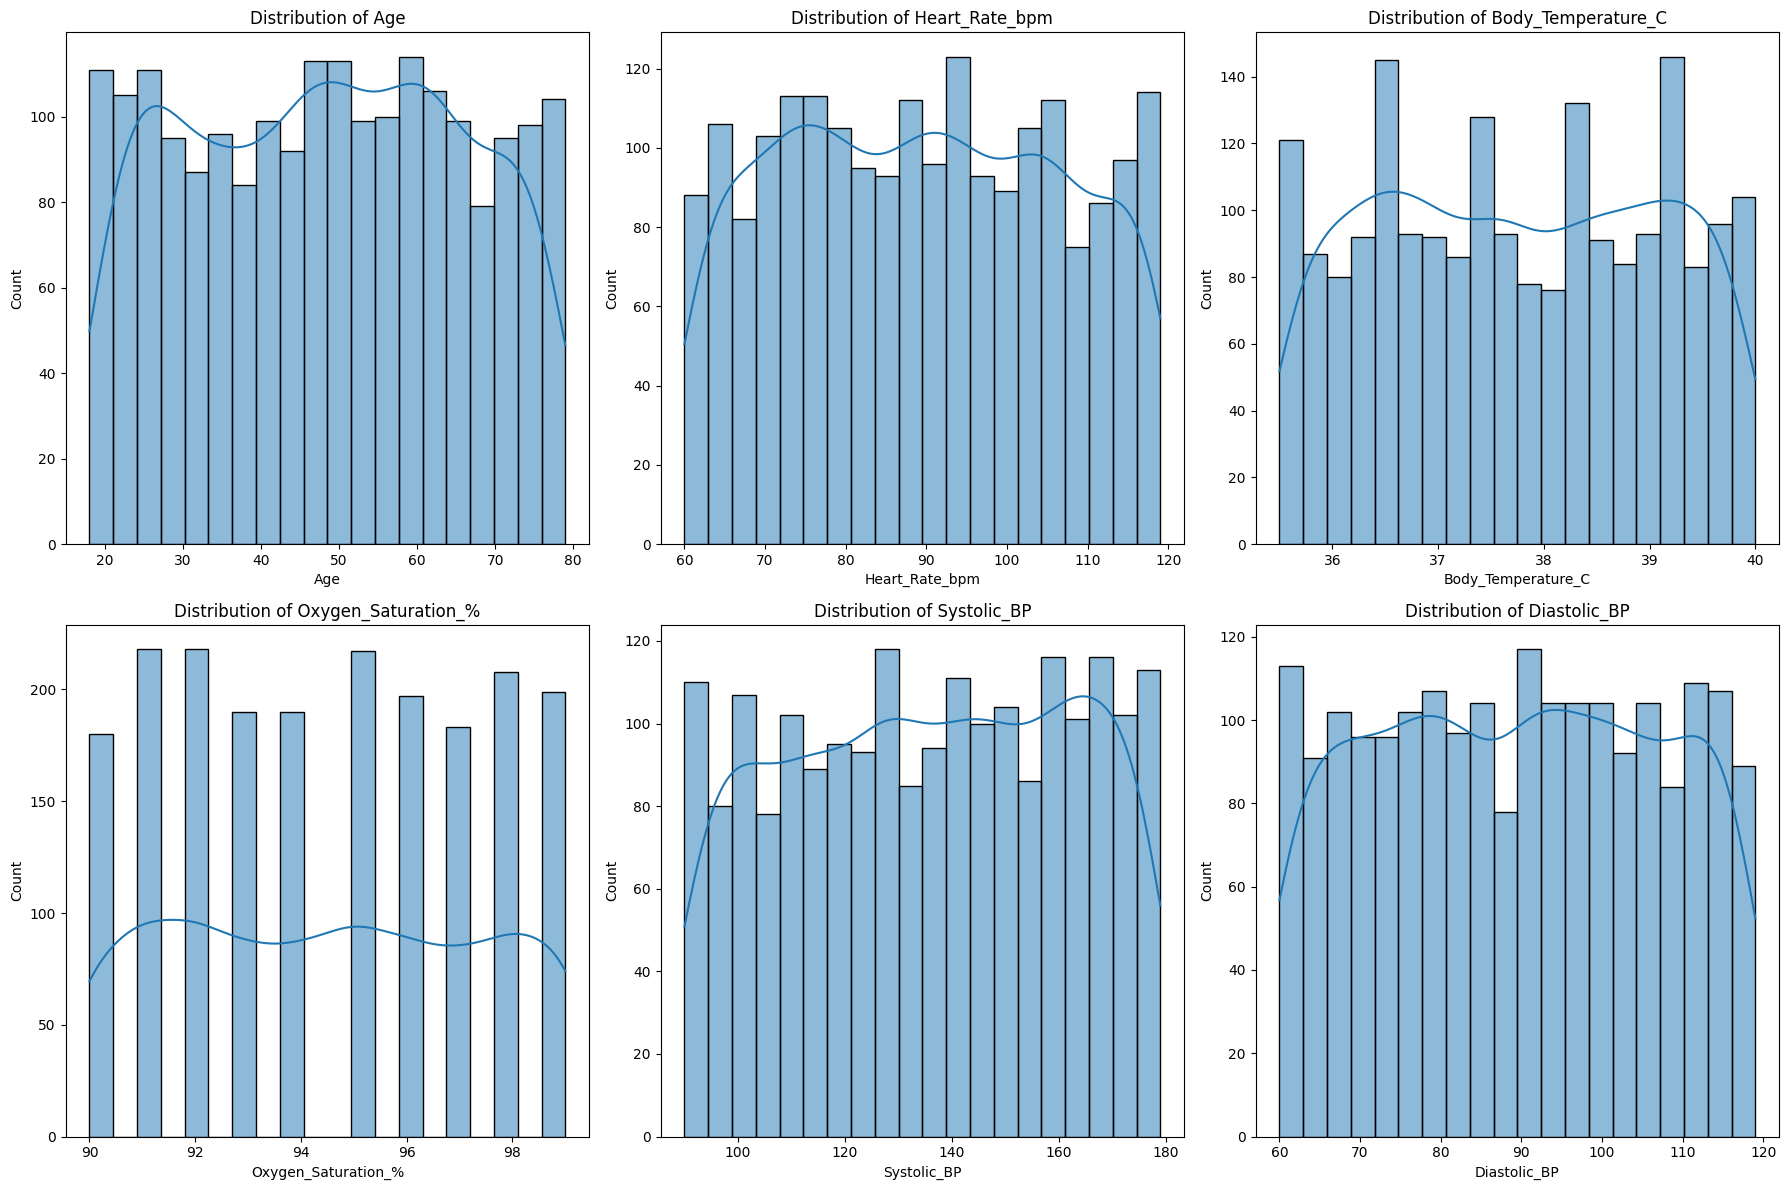


Distribution of Categorical Features:


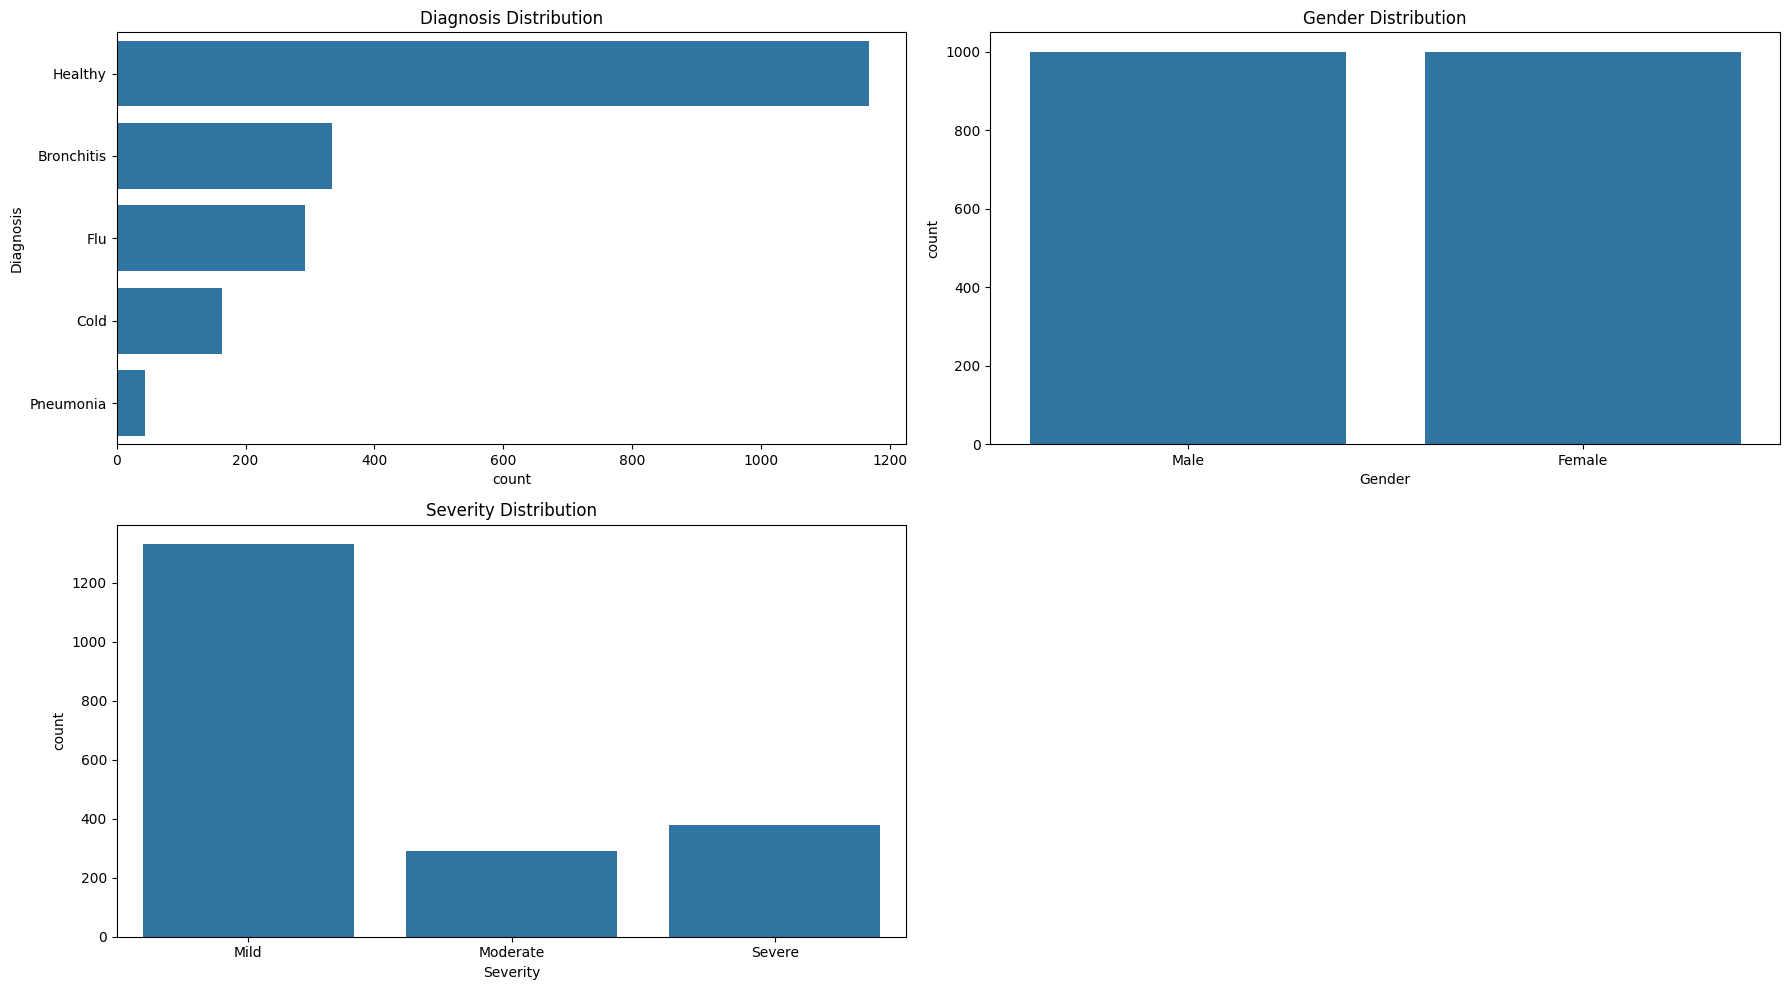

In [5]:
# Define numerical and categorical features
numerical_features = ['Age', 'Heart_Rate_bpm', 'Body_Temperature_C', 'Oxygen_Saturation_%', 'Systolic_BP', 'Diastolic_BP']
categorical_features = ['Gender', 'Symptom_1', 'Symptom_2', 'Symptom_3', 'Diagnosis', 'Severity', 'Treatment_Plan']

# Plot distributions for numerical features
print("\nDistribution of Numerical Features:")
plt.figure(figsize=(18, 12))
for i, col in enumerate(numerical_features):
    plt.subplot(2, 3, i + 1)
    sns.histplot(df[col], kde=True, bins=20)
    plt.title(f'Distribution of {col}')
plt.tight_layout()
plt.show()

# Plot counts for key categorical features
print("\nDistribution of Categorical Features:")
plt.figure(figsize=(18, 10))
# Diagnosis
plt.subplot(2, 2, 1)
sns.countplot(y=df['Diagnosis'], order=df['Diagnosis'].value_counts().index)
plt.title('Diagnosis Distribution')
# Gender
plt.subplot(2, 2, 2)
sns.countplot(x=df['Gender'])
plt.title('Gender Distribution')
# Severity
plt.subplot(2, 2, 3)
sns.countplot(x=df['Severity'], order=['Mild', 'Moderate', 'Severe'])
plt.title('Severity Distribution')
plt.tight_layout()
plt.show()

Insights:

Numerical Features: The distributions of features like Age, Heart_Rate_bpm, and Body_Temperature_C appear to be somewhat normally distributed, which is good for scaling and modeling.

Class Imbalance: The Diagnosis distribution reveals a significant class imbalance. The 'Healthy' class is the majority, while Pneumonia has very few samples. This must be addressed.

Bivariate Analysis: Relationships

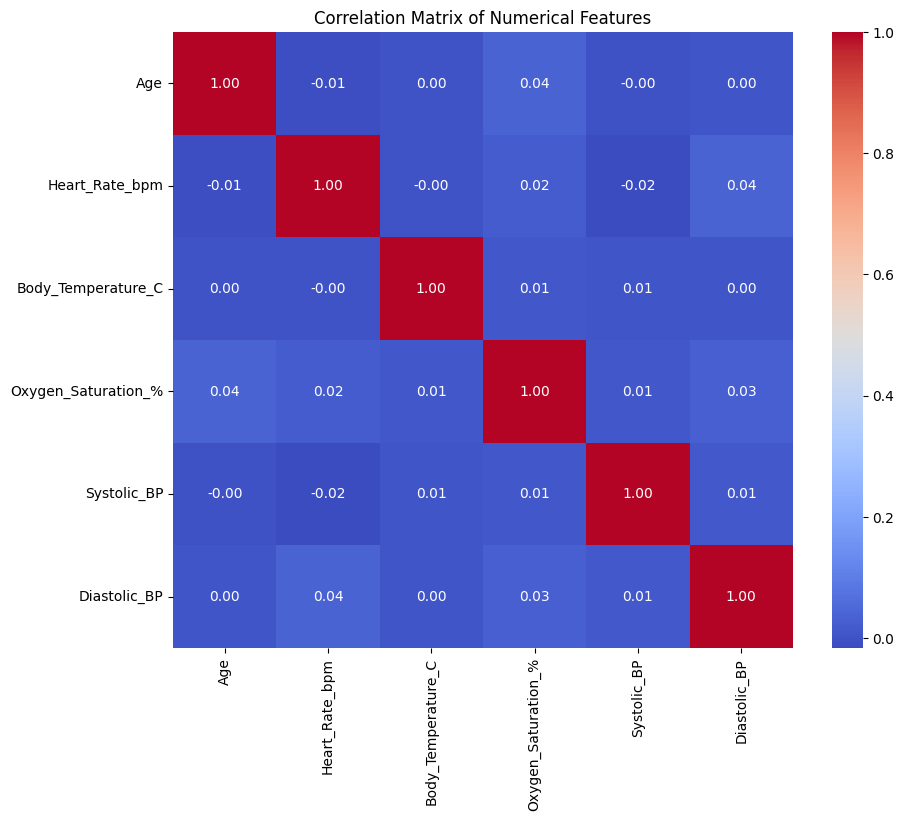

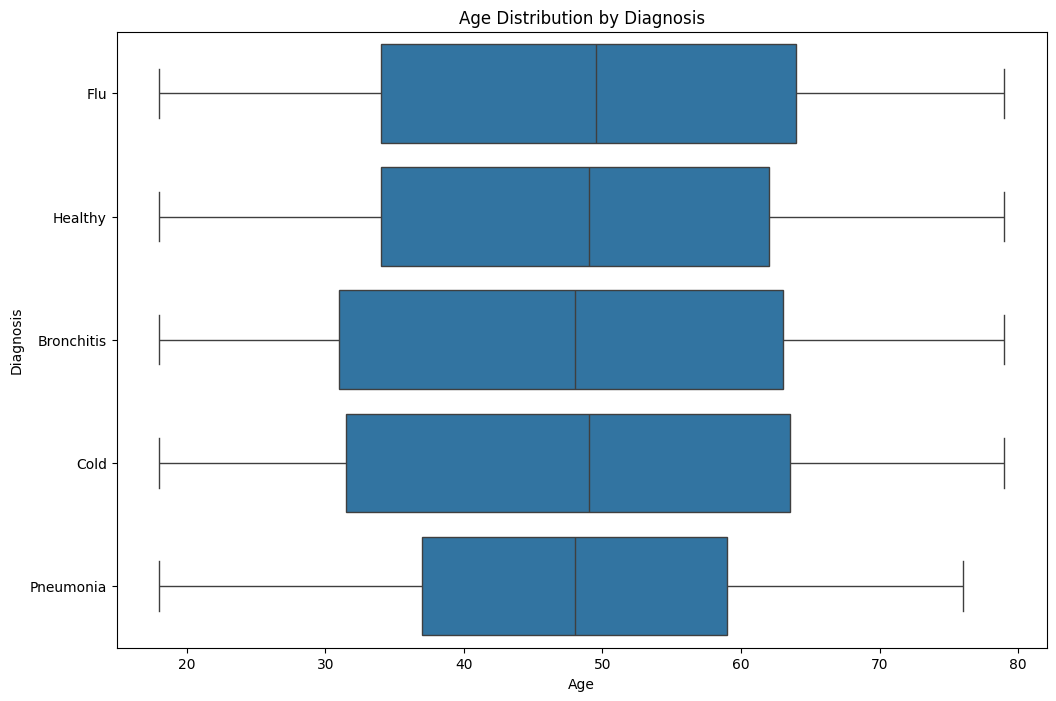

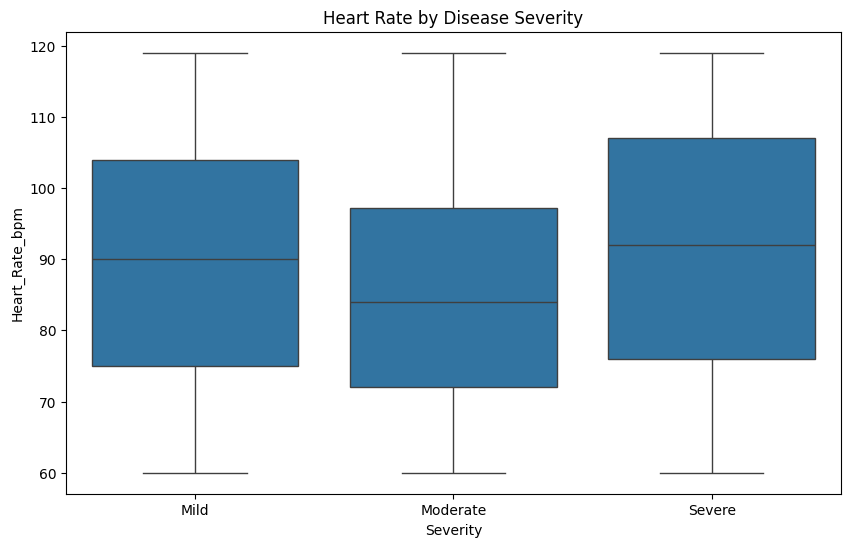

In [6]:
# Correlation heatmap for numerical features
plt.figure(figsize=(10, 8))
sns.heatmap(df[numerical_features].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix of Numerical Features')
plt.show()

# Age vs. Diagnosis
plt.figure(figsize=(12, 8))
sns.boxplot(x='Age', y='Diagnosis', data=df)
plt.title('Age Distribution by Diagnosis')
plt.show()

# Heart Rate vs. Severity
plt.figure(figsize=(10, 6))
sns.boxplot(x='Severity', y='Heart_Rate_bpm', data=df, order=['Mild', 'Moderate', 'Severe'])
plt.title('Heart Rate by Disease Severity')
plt.show()

Insights:

Correlation: The heatmap shows that Systolic_BP and Diastolic_BP are strongly correlated, as expected. There are no other extremely high correlations.

Age and Diagnosis: The boxplot for Age vs. Diagnosis suggests that certain diagnoses like 'Flu' and 'Bronchitis' might be more common in specific age groups.


-Model training
-Model evaluation

Initial Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 13 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Patient_ID           2000 non-null   int64  
 1   Age                  2000 non-null   int64  
 2   Gender               2000 non-null   object 
 3   Symptom_1            2000 non-null   object 
 4   Symptom_2            2000 non-null   object 
 5   Symptom_3            2000 non-null   object 
 6   Heart_Rate_bpm       2000 non-null   int64  
 7   Body_Temperature_C   2000 non-null   float64
 8   Blood_Pressure_mmHg  2000 non-null   object 
 9   Oxygen_Saturation_%  2000 non-null   int64  
 10  Diagnosis            2000 non-null   object 
 11  Severity             2000 non-null   object 
 12  Treatment_Plan       2000 non-null   object 
dtypes: float64(1), int64(4), object(8)
memory usage: 203.2+ KB
None


Training set shape: (1600, 10)
Testing set shape: 

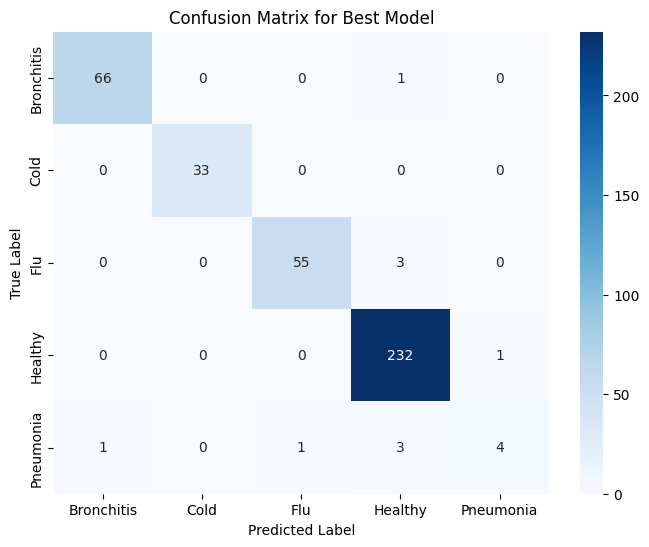

In [4]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight

warnings.filterwarnings('ignore')

# --- 1. Data Loading and Feature Engineering ---
# Load the dataset
try:
    # df = pd.read_csv("disease_diagnosis.csv")
    df = pd.read_csv("../Data/disease_diagnosis.csv")
except FileNotFoundError:
    print("Error: 'disease_diagnosis.csv' not found. Please ensure it is in the same directory.")
    exit()

print("Initial Dataset Info:")
print(df.info())
print("\n" + "="*50 + "\n")

# Drop 'Patient_ID' and non-predictive output columns
df.drop(['Patient_ID', 'Severity', 'Treatment_Plan'], axis=1, inplace=True)

# Split 'Blood_Pressure_mmHg'
df[['Systolic_BP', 'Diastolic_BP']] = df['Blood_Pressure_mmHg'].str.split('/', expand=True)
df['Systolic_BP'] = pd.to_numeric(df['Systolic_BP'])
df['Diastolic_BP'] = pd.to_numeric(df['Diastolic_BP'])
df.drop('Blood_Pressure_mmHg', axis=1, inplace=True)

# --- 2. Preprocessing & Data Splitting ---
# Define features (X) and the single target (y)
X = df.drop('Diagnosis', axis=1)
y = df['Diagnosis']

# Define feature types for preprocessing
numerical_features = ['Age', 'Heart_Rate_bpm', 'Body_Temperature_C', 'Oxygen_Saturation_%', 'Systolic_BP', 'Diastolic_BP']
nominal_categorical_features = ['Gender', 'Symptom_1', 'Symptom_2', 'Symptom_3']

# Create the preprocessing pipeline
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('nom', OneHotEncoder(handle_unknown='ignore'), nominal_categorical_features)
    ],
    remainder='passthrough'
)

# Split data into training and testing sets with stratification
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training set shape: {X_train.shape}")
print(f"Testing set shape: {X_test.shape}")
print("\n" + "="*50 + "\n")

# --- 3. Model Training with Class Imbalance Handling ---
# Use LabelEncoder to convert string labels to numbers
le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train)
y_test_encoded = le.transform(y_test)
class_labels = list(le.classes_)

# Define models and their hyperparameters, including class_weight
models = {
    "Random Forest": RandomForestClassifier(random_state=42),
    "Logistic Regression": LogisticRegression(random_state=42, solver='liblinear', max_iter=1000),
}

params = {
    "Random Forest": {
        'classifier__n_estimators': [50, 100],
        'classifier__max_depth': [10, None],
        'classifier__class_weight': ['balanced', None]
    },
    "Logistic Regression": {
        'classifier__C': [0.1, 1.0],
        'classifier__class_weight': ['balanced', None]
    }
}

best_model = None
best_score = 0
model_report = {}

for name, model in models.items():
    print(f"--- Training {name} with GridSearchCV ---")
    
    # Create the full pipeline including the preprocessor and the model
    model_pipeline = Pipeline(steps=[('preprocessor', preprocessor), ('classifier', model)])
    
    # Use GridSearchCV to find the best hyperparameters
    gs = GridSearchCV(model_pipeline, params[name], cv=3, scoring='f1_weighted', verbose=1)
    gs.fit(X_train, y_train)
    
    current_best_model = gs.best_estimator_
    
    y_pred = current_best_model.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    
    model_report[name] = accuracy
    
    if accuracy > best_score:
        best_score = accuracy
        best_model = current_best_model

print("\n" + "="*50 + "\n")
print("Model Training Report:")
for name, acc in model_report.items():
    print(f"  - {name}: {acc:.4f}")

print(f"\nBest Model: {best_model.named_steps['classifier'].__class__.__name__} with Accuracy: {best_score:.4f}")
print("\n" + "="*50 + "\n")

# --- 4. Final Evaluation of the Best Model ---
print("Final Evaluation of the Best Model:")
y_pred = best_model.predict(X_test)

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=class_labels))

# --- 5. Visualization ---
print("\nConfusion Matrix:")
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_labels, yticklabels=class_labels)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title(f'Confusion Matrix for Best Model')
plt.show()

-Applying smote
-Model training
-Model evaluation

Initial Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 13 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Patient_ID           2000 non-null   int64  
 1   Age                  2000 non-null   int64  
 2   Gender               2000 non-null   object 
 3   Symptom_1            2000 non-null   object 
 4   Symptom_2            2000 non-null   object 
 5   Symptom_3            2000 non-null   object 
 6   Heart_Rate_bpm       2000 non-null   int64  
 7   Body_Temperature_C   2000 non-null   float64
 8   Blood_Pressure_mmHg  2000 non-null   object 
 9   Oxygen_Saturation_%  2000 non-null   int64  
 10  Diagnosis            2000 non-null   object 
 11  Severity             2000 non-null   object 
 12  Treatment_Plan       2000 non-null   object 
dtypes: float64(1), int64(4), object(8)
memory usage: 203.2+ KB
None


Training set shape (before SMOTE): (1600, 10)
Test

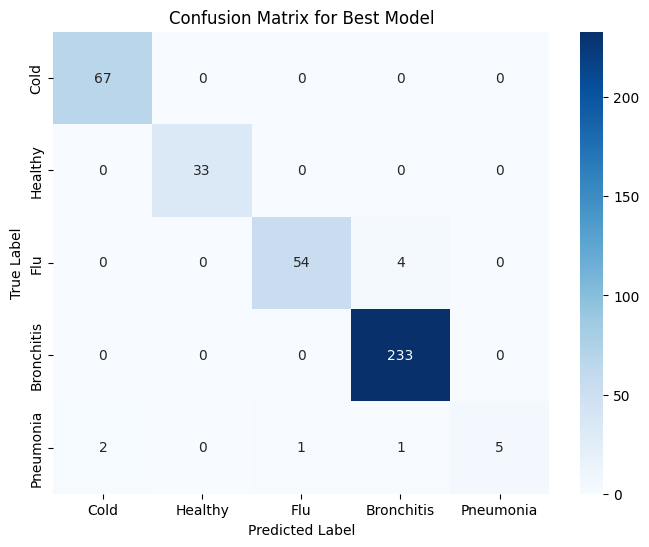

In [ ]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from imblearn.over_sampling import SMOTE

warnings.filterwarnings('ignore')

# --- 1. Data Loading and Feature Engineering ---
# Load the dataset
try:

    df = pd.read_csv("../Data/disease_diagnosis.csv")
except FileNotFoundError:
    print("Error: 'disease_diagnosis.csv' not found. Please ensure it is in the same directory.")
    exit()

print("Initial Dataset Info:")
print(df.info())
print("\n" + "="*50 + "\n")

# Drop 'Patient_ID' and non-predictive output columns
df.drop(['Patient_ID', 'Severity', 'Treatment_Plan'], axis=1, inplace=True)

# Split 'Blood_Pressure_mmHg'
df[['Systolic_BP', 'Diastolic_BP']] = df['Blood_Pressure_mmHg'].str.split('/', expand=True)
df['Systolic_BP'] = pd.to_numeric(df['Systolic_BP'])
df['Diastolic_BP'] = pd.to_numeric(df['Diastolic_BP'])
df.drop('Blood_Pressure_mmHg', axis=1, inplace=True)

# --- 2. Preprocessing & Data Splitting ---
# Define features (X) and the single target (y)
X = df.drop('Diagnosis', axis=1)
y = df['Diagnosis']

# Define feature types for preprocessing
numerical_features = ['Age', 'Heart_Rate_bpm', 'Body_Temperature_C', 'Oxygen_Saturation_%', 'Systolic_BP', 'Diastolic_BP']
nominal_categorical_features = ['Gender', 'Symptom_1', 'Symptom_2', 'Symptom_3']

# Create the preprocessing pipeline for features
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('nom', OneHotEncoder(handle_unknown='ignore'), nominal_categorical_features)
    ],
    remainder='passthrough'
)

# Split data into training and testing sets with stratification
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training set shape (before SMOTE): {X_train.shape}")
print(f"Testing set shape: {X_test.shape}")
print("\n" + "="*50 + "\n")

# --- 3. Applying SMOTE to the Training Data ---
# Preprocess the training data first, then applying SMOTE
X_train_preprocessed = preprocessor.fit_transform(X_train)
X_test_preprocessed = preprocessor.transform(X_test)

print("Class distribution before SMOTE:")
print(y_train.value_counts())

smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_preprocessed, y_train)

print("\nClass distribution after SMOTE:")
print(y_train_resampled.value_counts())
print("\n" + "="*50 + "\n")

# --- 4. Model Training and Evaluation ---
# Define models and their hyperparameters
models = {
    "Random Forest": RandomForestClassifier(random_state=42),
    "Logistic Regression": LogisticRegression(random_state=42, solver='liblinear', max_iter=1000),
}

params = {
    "Random Forest": {
        'n_estimators': [50, 100],
        'max_depth': [10, None],
        'class_weight': ['balanced', None]
    },
    "Logistic Regression": {
        'C': [0.1, 1.0],
        'class_weight': ['balanced', None]
    }
}

best_model = None
best_score = 0
model_report = {}

for name, model in models.items():
    print(f"--- Training {name} with GridSearchCV ---")
    
    # We apply GridSearchCV directly to the model and preprocessed data
    gs = GridSearchCV(model, params[name], cv=3, scoring='f1_weighted', verbose=1)
    # Fit on the SMOTE-resampled training data
    gs.fit(X_train_resampled, y_train_resampled)
    
    current_best_model = gs.best_estimator_
    
    # Predict on the original, untouched test set
    y_pred = current_best_model.predict(X_test_preprocessed)
    accuracy = accuracy_score(y_test, y_pred)
    
    model_report[name] = accuracy
    
    if accuracy > best_score:
        best_score = accuracy
        best_model = current_best_model

print("\n" + "="*50 + "\n")
print("Model Training Report:")
for name, acc in model_report.items():
    print(f"  - {name}: {acc:.4f}")

print(f"\nBest Model: {best_model.__class__.__name__} with Accuracy: {best_score:.4f}")
print("\n" + "="*50 + "\n")

# --- 5. Final Evaluation of the Best Model ---
print("Final Evaluation of the Best Model:")
y_pred = best_model.predict(X_test_preprocessed)

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=y_test.unique()))

# --- 6. Visualization ---
print("\nConfusion Matrix:")
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=y_test.unique(), yticklabels=y_test.unique())
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title(f'Confusion Matrix for Best Model')
plt.show()

Insights
-The Random Forest classifier achieved an accuracy of 98.00%, significantly outperforming Logistic Regression.

------------------------------- New code -----------------------

Import Libraries

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Loading Data and getting basic info

In [13]:
df = pd.read_csv("../Data/disease_data1.csv")

# Show first rows
print(df.head())

print("\nDataset Info:")
print(df.info())

print("\nMissing Values:")
print(df.isnull().sum())

print("\nSummary Statistics:")
print(df.describe(include="all"))

   Patient_ID  Age  Gender  Heart_Rate_bpm  Body_Temperature_C  \
0           1   68    Male             103               39.38   
1           2   66  Female             103               36.89   
2           3   49    Male             118               37.78   
3           4   70    Male              90               36.30   
4           5   57  Female              92               36.00   

   Oxygen_Saturation_%            Symptom_1            Symptom_2  \
0                92.60          Sore throat          Sore throat   
1                94.69            Body ache                Fever   
2                94.19  Shortness of breath             Headache   
3                97.59  Shortness of breath  Shortness of breath   
4                96.60           Runny nose          Sore throat   

             Symptom_3 Blood_Pressure_mmHg  Severity       Treatment_Plan  \
0                Fever              121/94  Moderate  Medication and rest   
1  Shortness of breath              103/

Insights-

-No Missing Values
-Correct Data Types
-Normal Value Ranges

In [14]:
# Blood pressure has combined value so split it
if "Blood_Pressure_mmHg" in df.columns:
    bp_split = df["Blood_Pressure_mmHg"].str.split("/", expand=True)
    df["Systolic_BP"] = pd.to_numeric(bp_split[0], errors="coerce")
    df["Diastolic_BP"] = pd.to_numeric(bp_split[1], errors="coerce")
    df.drop(columns=["Blood_Pressure_mmHg"], inplace=True)
df

,Patient_ID,Age,Gender,Heart_Rate_bpm,Body_Temperature_C,Oxygen_Saturation_%,Symptom_1,Symptom_2,Symptom_3,Severity,Treatment_Plan,Diagnosis,Systolic_BP,Diastolic_BP
0,1,68,Male,103,39.38,92.60,Sore throat,Sore throat,Fever,Moderate,Medication and rest,Flu,121,94
1,2,66,Female,103,36.89,94.69,Body ache,Fever,Shortness of breath,Mild,Rest and fluids,Healthy,103,79
2,3,49,Male,118,37.78,94.19,Shortness of breath,Headache,Headache,Mild,Rest and fluids,Healthy,106,81
3,4,70,Male,90,36.30,97.59,Shortness of breath,Shortness of breath,Fatigue,Mild,Rest and fluids,Cold,102,72
4,5,57,Female,92,36.00,96.60,Runny nose,Sore throat,Body ache,Mild,Rest and fluids,Cold,120,85
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1995,1996,57,Male,106,38.73,94.30,Shortness of breath,Fever,Cough,Moderate,Medication and rest,Flu,137,78
1996,1997,32,Male,113,38.04,98.18,Shortness of breath,Headache,Shortness of breath,Mild,Rest and fluids,Healthy,101,84
1997,1998,43,Female,66,38.88,91.01,Fever,Cough,Sore throat,Severe,Hospitalization and medication,Bronchitis,123,82
1998,1999,61,Male,103,36.05,96.98,Cough,Shortness of breath,Fatigue,Mild,Rest and fluids,Healthy,125,73


In [15]:
# Convert categorical columns to category dtype
cat_cols = ["Gender", "Symptom_1", "Symptom_2", "Symptom_3", 
            "Diagnosis", "Severity", "Treatment_Plan"]

for col in cat_cols:
    if col in df.columns:
        df[col] = df[col].astype("category")

Univariate Analysis

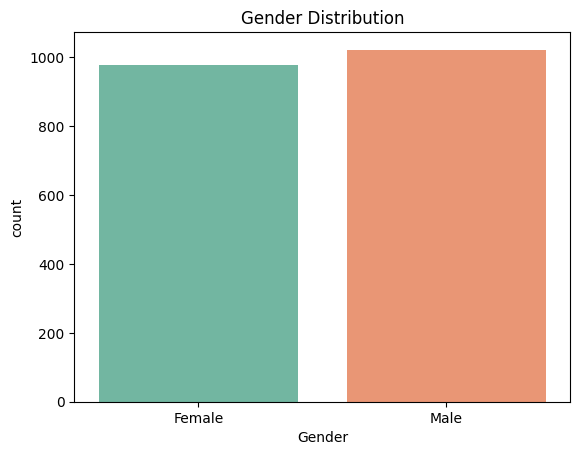

In [26]:
# Gender counts
sns.countplot(data=df, x="Gender",hue="Gender", palette="Set2")
plt.title("Gender Distribution")
plt.show()

Insights-
-Gender distribution is balanced

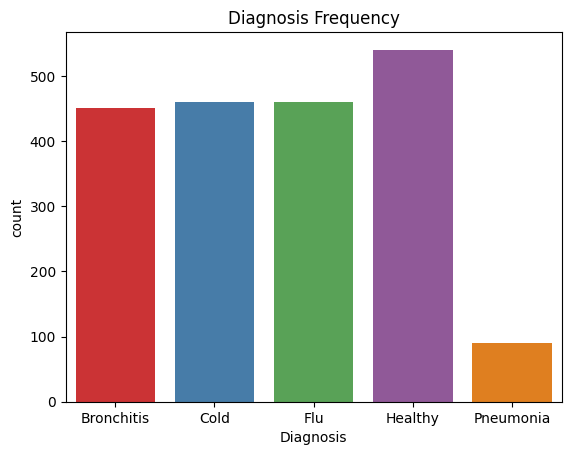

In [25]:
# Diagnosis counts
sns.countplot(data=df, x="Diagnosis",hue="Diagnosis", palette="Set1")
plt.title("Diagnosis Frequency")
plt.show()

Insights-
-Healthy is the most frequent category
-Bronchitis, Cold, and Flu—are all well-represented and have almost similar count
-Pneumonia is the distinct minority class
-There is imbalance issue ,need to resolve

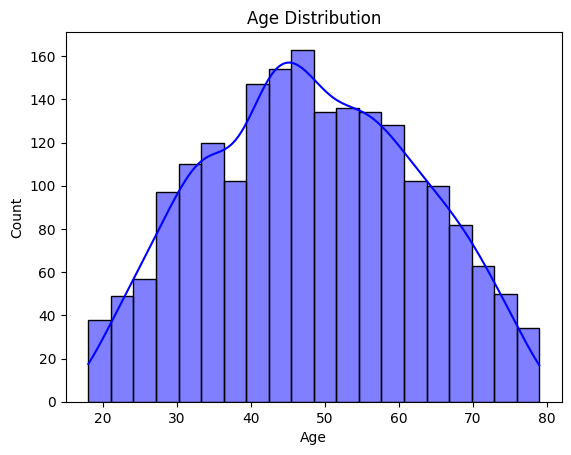

In [18]:
# Age distribution
sns.histplot(df["Age"], kde=True, bins=20, color="blue")
plt.title("Age Distribution")
plt.show()

Insights-
-The vast majority of patients are middle-aged adults, roughly between 35 and 60 years old

Symptoms Analysis

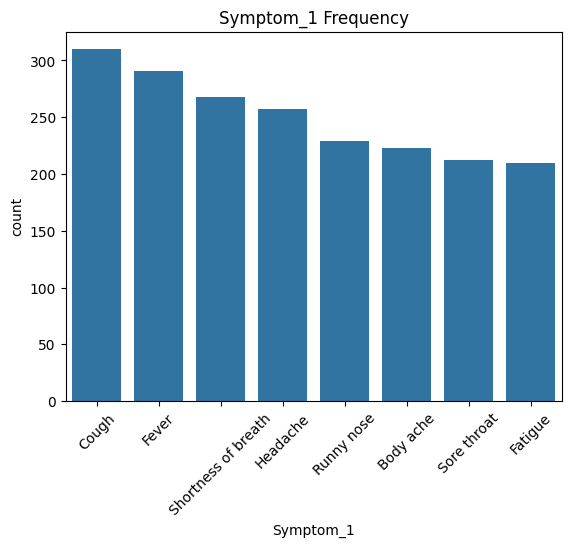

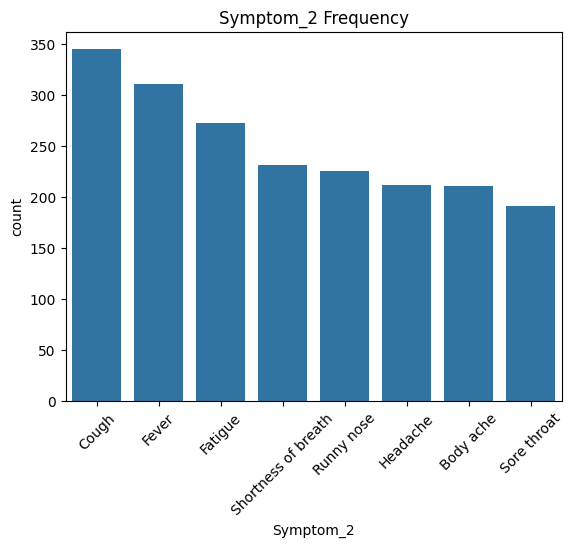

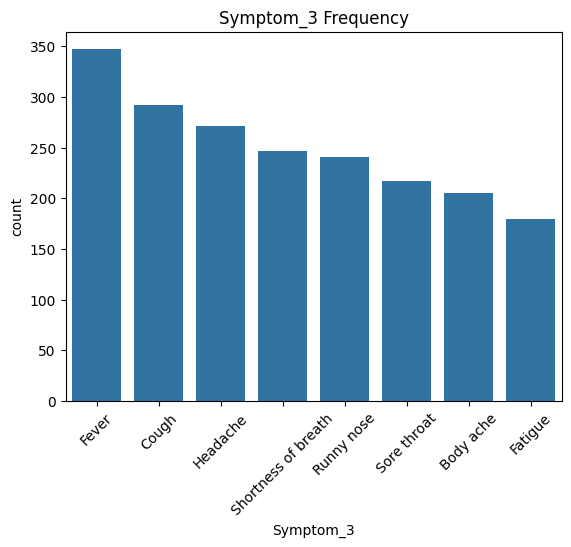

In [19]:
for symptom in ["Symptom_1", "Symptom_2", "Symptom_3"]:
    if symptom in df.columns:
        sns.countplot(data=df, x=symptom, order=df[symptom].value_counts().index)
        plt.title(f"{symptom} Frequency")
        plt.xticks(rotation=45)
        plt.show()

Insights-
-Cough and Fever are consistently the most frequent primary, secondary, and tertiary symptoms.
-The distribution of all 8 symptoms is relatively balanced within each symptom column

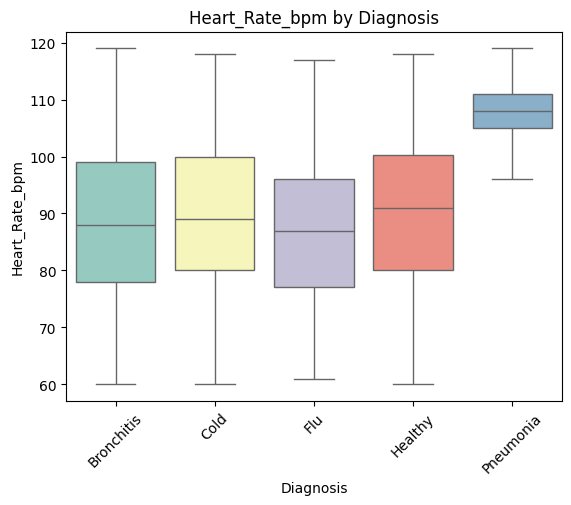

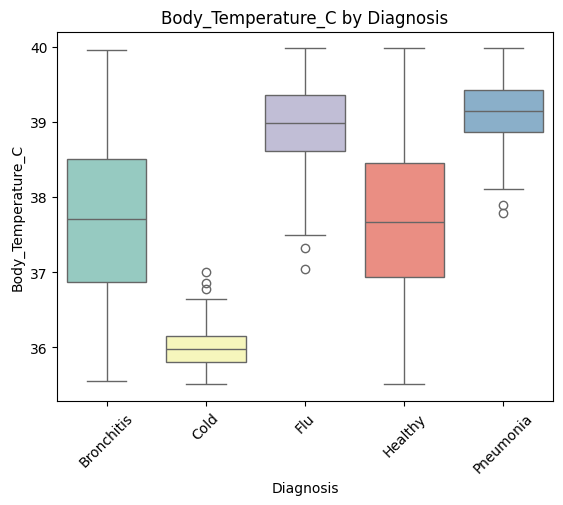

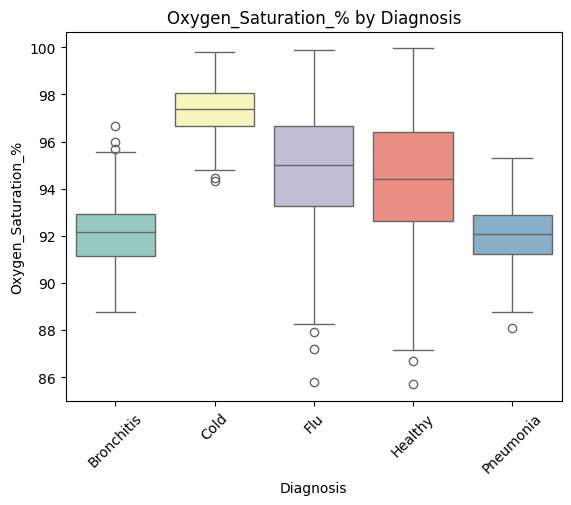

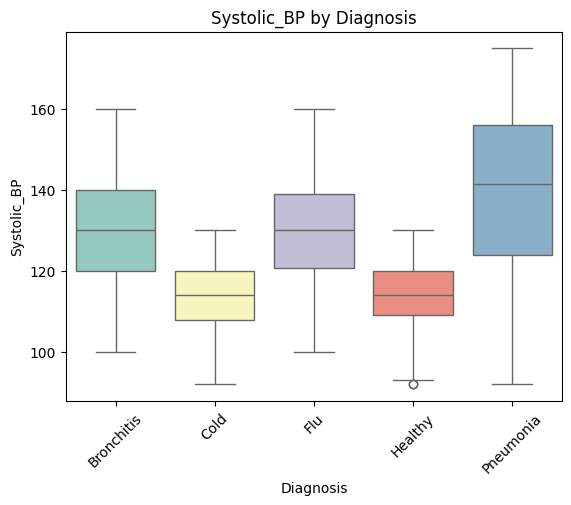

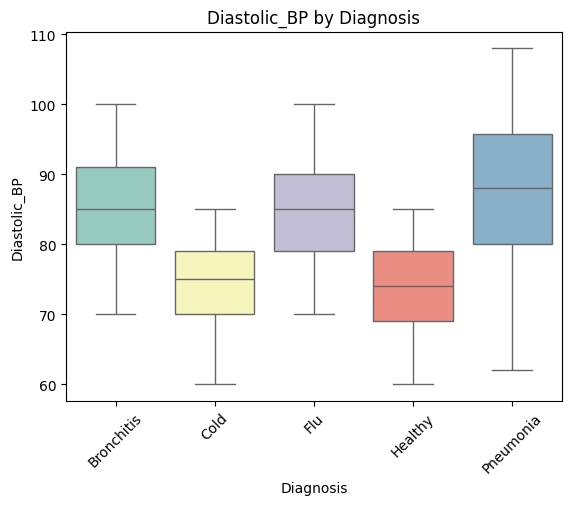

In [23]:
# Boxplots of vitals by Diagnosis
for col in ["Heart_Rate_bpm", "Body_Temperature_C", "Oxygen_Saturation_%", "Systolic_BP", "Diastolic_BP"]:
    if col in df.columns:
        sns.boxplot(data=df, x="Diagnosis", y=col, hue="Diagnosis", palette="Set3", legend=False)
        plt.title(f"{col} by Diagnosis")
        plt.xticks(rotation=45)
        plt.show()


Insights-
-The Pneumonia class stands out clearly from the others across multiple vitals
-The heart rate for Pneumonia is dramatically higher than for any other condition.
-High fever is a key feature for both Flu and Pneumonia
-Temperature is less for cold
-Low oxygen saturation is characteristic of Pneumonia and Bronchitis


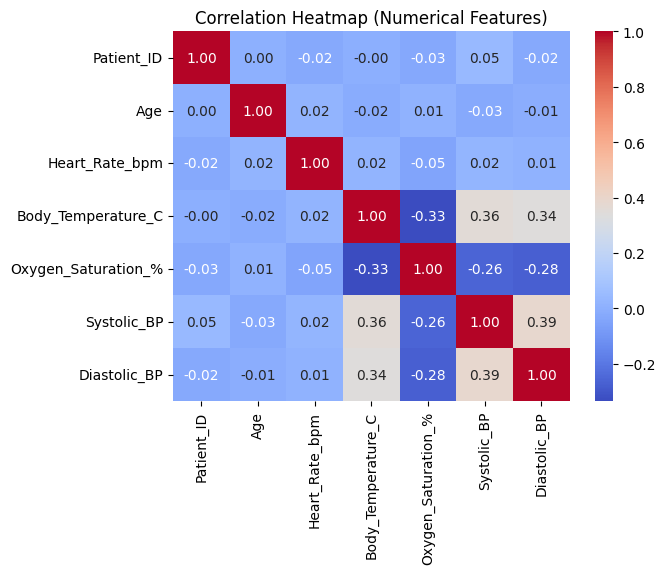

In [ ]:
# Correlation Analysis

num_cols = df.select_dtypes(include=[np.number]).columns
corr = df[num_cols].corr()

sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap (Numerical Features)")
plt.show()

-Insights
-Most of the squares in the heatmap are light blue, white, or light orange
-It means that most of the numerical features are independent and not strongly correlated with each other. 

Multivariate Analysis

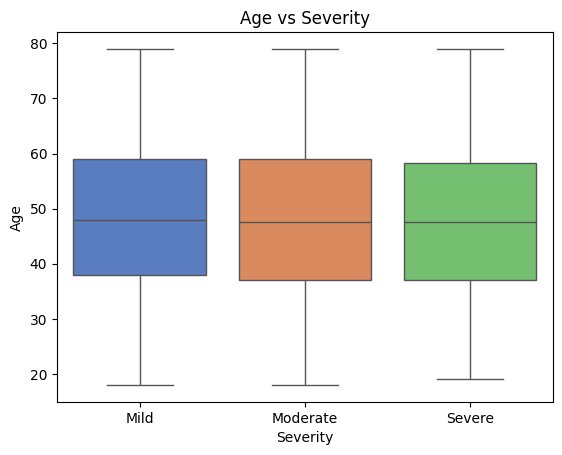

In [30]:
# Age vs Severity
sns.boxplot(data=df, x="Severity", y="Age",hue="Severity" ,palette="muted")
plt.title("Age vs Severity")
plt.show()

Insight-
-there appears to be no clear relationship between a patient's Age and the Severity of their diagnosis.

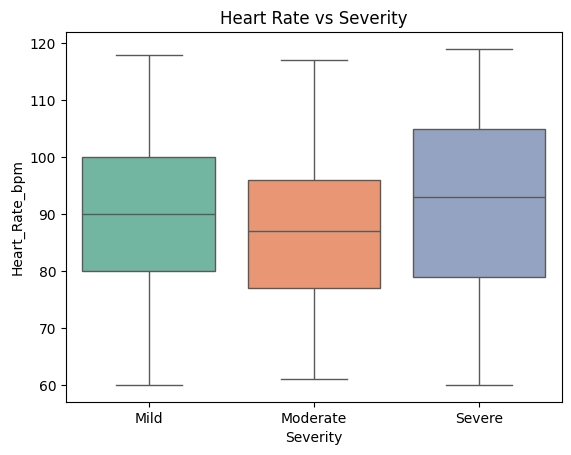

In [33]:
# Heart Rate vs Severity
sns.boxplot(data=df, x="Severity", y="Heart_Rate_bpm",hue="Severity", palette="Set2")
plt.title("Heart Rate vs Severity")
plt.show()

Insights
-Heart rate shows a relationship with severity; the median heart rate for 'Severe' cases is higher than for 'Mild' and 'Moderate'.

In [34]:
import pandas as pd
import numpy as np
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

In [ ]:
# 4. Define Features (X) and Target (y)
# ==============================
# The target variable is 'Diagnosis'
y = df["Diagnosis"]

X = df.drop(columns=["Diagnosis", "Patient_ID", "Severity", "Treatment_Plan"])

print("\nShape of feature set (X):", X.shape)
print("Shape of target set (y):", y.shape)


Shape of feature set (X): (2000, 10)
Shape of target set (y): (2000,)


In [36]:
# ==============================
# 5. Build the Preprocessing Pipeline
# ==============================
print("\nBuilding the ColumnTransformer preprocessing pipeline...")

# Automatically identify numerical and categorical feature names from X
numerical_features = X.select_dtypes(include=np.number).columns.tolist()
categorical_features = X.select_dtypes(exclude=np.number).columns.tolist()

print("\nIdentified Numerical Features:")
print(numerical_features)
print("\nIdentified Categorical Features:")
print(categorical_features)


Building the ColumnTransformer preprocessing pipeline...

Identified Numerical Features:
['Age', 'Heart_Rate_bpm', 'Body_Temperature_C', 'Oxygen_Saturation_%', 'Systolic_BP', 'Diastolic_BP']

Identified Categorical Features:
['Gender', 'Symptom_1', 'Symptom_2', 'Symptom_3']
